# Phishing URL Classification — Ensemble Model

This notebook trains all base models and combines them into a **soft-voting ensemble**.

### Base models
| # | Model | Data track |
|---|---|---|
| 1 | Logistic Regression (no penalty) | Linear (scaled) |
| 2 | Logistic Regression L2 | Linear (scaled) |
| 3 | Logistic Regression L1 | Linear (scaled) |
| 4 | Elastic Net | Linear (scaled) |
| 5 | PCR (PCA + Logistic) | Linear (scaled) |
| 6 | Forward Stepwise Logit | Linear (scaled) |
| 7 | Backward Stepwise Logit | Linear (scaled) |
| 8 | Random Forest | Tree (unscaled) |
| 9 | XGBoost | Tree (unscaled) |

### Ensemble strategy
**Soft voting** — each base model produces a probability for class 1 (legitimate).
The ensemble prediction is the unweighted average of these probabilities.
The final label is 1 if the average probability ≥ 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
import itertools

from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42

## 1. Load Data

In [2]:
# Linear track (scaled) — used by logistic / stepwise / PCR models
df_train_lin = pd.read_csv('../data/processed/train_lin.csv')
df_test_lin  = pd.read_csv('../data/processed/test_lin.csv')

X_train_lin = df_train_lin.drop('label', axis=1)
y_train     = df_train_lin['label']
X_test_lin  = df_test_lin.drop('label', axis=1)
y_test      = df_test_lin['label']

# Tree track (unscaled) — used by RF and XGBoost
df_train_tree = pd.read_csv('../data/processed/train_tree.csv')
df_test_tree  = pd.read_csv('../data/processed/test_tree.csv')

X_train_tree = df_train_tree.drop('label', axis=1)
X_test_tree  = df_test_tree.drop('label', axis=1)

print(f'Linear track  — train: {X_train_lin.shape}, test: {X_test_lin.shape}')
print(f'Tree track    — train: {X_train_tree.shape}, test: {X_test_tree.shape}')
print(f'Class balance — train legitimate rate: {y_train.mean():.3f}')

Linear track  — train: (188636, 22), test: (47159, 22)
Tree track    — train: (188636, 22), test: (47159, 22)
Class balance — train legitimate rate: 0.572


## 2. Cross-Validation Setup

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

folds_lin  = []
folds_tree = []

for train_idx, val_idx in skf.split(X_train_lin, y_train):
    folds_lin.append((
        X_train_lin.iloc[train_idx],  y_train.iloc[train_idx],
        X_train_lin.iloc[val_idx],    y_train.iloc[val_idx]
    ))
    folds_tree.append((
        X_train_tree.iloc[train_idx], y_train.iloc[train_idx],
        X_train_tree.iloc[val_idx],   y_train.iloc[val_idx]
    ))

print(f'Prepared {len(folds_lin)} folds (linear + tree tracks).')

Prepared 5 folds (linear + tree tracks).


## 3. Train Base Models

Each model is fit on the full training set using the best hyperparameters found
via 5-fold CV in the individual model notebooks (or re-tuned here for completeness).

### 3.1 Logistic Regression (no penalty)

In [4]:
lr_none = LogisticRegression(penalty=None, random_state=SEED, max_iter=1000)
lr_none.fit(X_train_lin, y_train)
prob_lr_none = lr_none.predict_proba(X_test_lin)[:, 1]
print(f'LR (no penalty) — AUC: {roc_auc_score(y_test, prob_lr_none):.6f}')

LR (no penalty) — AUC: 0.998446


### 3.2 Logistic Regression L2 (Ridge) — CV over lambda

In [5]:
l2_lambdas = [0.01, 0.1, 1, 10, 100]
l2_cv_scores = {}

for lam in l2_lambdas:
    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds_lin:
        m = LogisticRegression(penalty='l2', C=1/lam, random_state=SEED, max_iter=1000)
        m.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, m.predict(X_val)))
    l2_cv_scores[lam] = np.mean(fold_accs)

best_l2_lam = max(l2_cv_scores, key=l2_cv_scores.get)
print(f'Best L2 lambda: {best_l2_lam}  (CV acc={l2_cv_scores[best_l2_lam]:.6f})')

lr_l2 = LogisticRegression(penalty='l2', C=1/best_l2_lam, random_state=SEED, max_iter=1000)
lr_l2.fit(X_train_lin, y_train)
prob_lr_l2 = lr_l2.predict_proba(X_test_lin)[:, 1]
print(f'LR L2 — AUC: {roc_auc_score(y_test, prob_lr_l2):.6f}')

Best L2 lambda: 0.01  (CV acc=0.997074)
LR L2 — AUC: 0.998606


### 3.3 Logistic Regression L1 (Lasso) — CV over lambda

In [6]:
l1_lambdas = [0.01, 0.1, 1, 10]
l1_cv_scores = {}

for lam in l1_lambdas:
    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds_lin:
        m = LogisticRegression(penalty='l1', solver='saga', C=1/lam,
                               max_iter=2000, tol=1e-3)
        m.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, m.predict(X_val)))
    l1_cv_scores[lam] = np.mean(fold_accs)

best_l1_lam = max(l1_cv_scores, key=l1_cv_scores.get)
print(f'Best L1 lambda: {best_l1_lam}  (CV acc={l1_cv_scores[best_l1_lam]:.6f})')

lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=1/best_l1_lam,
                            random_state=SEED, max_iter=2000)
lr_l1.fit(X_train_lin, y_train)
prob_lr_l1 = lr_l1.predict_proba(X_test_lin)[:, 1]
print(f'LR L1 — AUC: {roc_auc_score(y_test, prob_lr_l1):.6f}')

Best L1 lambda: 0.01  (CV acc=0.991693)
LR L1 — AUC: 0.998205


### 3.4 Elastic Net — CV over lambda and l1_ratio

In [7]:
en_lambdas   = [0.01, 0.1, 1, 10, 100]
en_l1_ratios = [0.1, 0.5, 0.9]
en_cv_scores = {}

for lam, l1r in itertools.product(en_lambdas, en_l1_ratios):
    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds_lin:
        m = LogisticRegression(penalty='elasticnet', solver='saga',
                               C=1/lam, l1_ratio=l1r,
                               random_state=SEED, max_iter=1000, tol=1e-3)
        m.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, m.predict(X_val)))
    en_cv_scores[(lam, l1r)] = np.mean(fold_accs)

best_en_lam, best_en_l1r = max(en_cv_scores, key=en_cv_scores.get)
print(f'Best EN lambda={best_en_lam}, l1_ratio={best_en_l1r}  '
      f'(CV acc={en_cv_scores[(best_en_lam, best_en_l1r)]:.6f})')

lr_en = LogisticRegression(penalty='elasticnet', solver='saga',
                            C=1/best_en_lam, l1_ratio=best_en_l1r,
                            random_state=SEED, max_iter=1000, tol=1e-3)
lr_en.fit(X_train_lin, y_train)
prob_lr_en = lr_en.predict_proba(X_test_lin)[:, 1]
print(f'Elastic Net — AUC: {roc_auc_score(y_test, prob_lr_en):.6f}')

Best EN lambda=0.01, l1_ratio=0.1  (CV acc=0.991688)
Elastic Net — AUC: 0.998102


### 3.5 Principal Component Regression (PCR)

In [8]:
# Use 9 components (chosen in ML_models_linear.ipynb from scree plot — ~90% variance)
N_COMPONENTS = 9

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_lin)
X_test_pca  = pca.transform(X_test_lin)

lr_pcr = LogisticRegression(random_state=SEED, max_iter=1000)
lr_pcr.fit(X_train_pca, y_train)
prob_pcr = lr_pcr.predict_proba(X_test_pca)[:, 1]
print(f'PCR ({N_COMPONENTS} components, {pca.explained_variance_ratio_.sum():.3f} var explained) '
      f'— AUC: {roc_auc_score(y_test, prob_pcr):.6f}')

PCR (9 components, 0.902 var explained) — AUC: 0.947814


### 3.6 Forward Stepwise Logit

In [9]:
def forward_stepwise_selection(X, y, p_enter=0.01, max_features=None, verbose=False):
    """
    Forward stepwise feature selection using p-values from statsmodels Logit.
    Stops when no remaining feature has p-value < p_enter.
    """
    selected = []
    remaining = list(X.columns)
    history = []

    if max_features is None:
        max_features = len(remaining)

    for step in range(max_features):
        best_feature = None
        best_p = np.inf
        best_model = None

        for feature in remaining:
            trial_features = selected + [feature]
            X_trial = sm.add_constant(X[trial_features], has_constant='add')
            try:
                model = sm.Logit(y, X_trial).fit(disp=0, method='lbfgs', maxiter=200)
                pval = model.pvalues.get(feature, np.inf)
            except Exception:
                continue

            if pval < best_p:
                best_p = pval
                best_feature = feature
                best_model = model

        if best_feature is None or best_p >= p_enter:
            if verbose:
                print(f'Stopping at step {step+1}: no feature met p < {p_enter}.')
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        history.append({
            'step': step + 1,
            'feature': best_feature,
            'p_value': float(best_p),
            'aic': float(best_model.aic),
            'bic': float(best_model.bic),
            'pseudo_r2': float(best_model.prsquared),
        })

        if verbose:
            print(f"Step {step+1}: added '{best_feature}' (p={best_p:.3e}, AIC={best_model.aic:.2f})")

    history_df = pd.DataFrame(history)
    return selected, history_df


selected_fwd, _ = forward_stepwise_selection(X_train_lin, y_train, p_enter=0.01, verbose=True)
print(f'\nForward selection: {len(selected_fwd)} features selected')

X_train_fwd_const = sm.add_constant(X_train_lin[selected_fwd], has_constant='add')
model_fwd = sm.Logit(y_train, X_train_fwd_const).fit(disp=0, method='lbfgs', maxiter=300)

X_test_fwd_const = sm.add_constant(X_test_lin[selected_fwd], has_constant='add')
prob_fwd = model_fwd.predict(X_test_fwd_const).values
print(f'Forward Stepwise Logit — AUC: {roc_auc_score(y_test, prob_fwd):.6f}')

Step 1: added 'URLLength' (p=0.000e+00, AIC=205642.12)
Step 2: added 'DomainLength' (p=0.000e+00, AIC=197670.32)
Step 3: added 'CharContinuationRate' (p=0.000e+00, AIC=182046.23)
Step 4: added 'URLCharProb' (p=0.000e+00, AIC=165465.93)
Step 5: added 'TLDLength' (p=0.000e+00, AIC=160831.11)
Step 6: added 'NoOfSubDomain' (p=0.000e+00, AIC=156351.69)
Step 7: added 'NoOfLettersInURL' (p=0.000e+00, AIC=147008.89)
Step 8: added 'NoOfDegitsInURL' (p=0.000e+00, AIC=58215.38)
Step 9: added 'LetterRatioInURL' (p=0.000e+00, AIC=56319.23)
Step 10: added 'DegitRatioInURL' (p=0.000e+00, AIC=52330.99)
Step 11: added 'SpacialCharRatioInURL' (p=0.000e+00, AIC=19711.49)
Step 12: added 'NoOfEqualsInURL' (p=2.090e-44, AIC=18449.05)
Step 13: added 'NoOfOtherSpecialCharsInURL' (p=6.311e-252, AIC=4507.52)
Stopping at step 14: no feature met p < 0.01.

Forward selection: 13 features selected
Forward Stepwise Logit — AUC: 0.998543


### 3.7 Backward Stepwise Logit

In [10]:
def backward_stepwise_selection(X, y, p_remove=0.05, min_features=1, verbose=False):
    """
    Backward stepwise feature selection for statsmodels Logit.

    Primary rule:
    - Remove feature with highest p-value if that p-value > p_remove.

    Fallback rule (when p-values are all NaN due to Hessian/covariance issues):
    - Try one-feature removal candidates and remove the feature that gives the
      best AIC only if AIC improves.
    """
    selected = list(X.columns)
    history = []

    while len(selected) > min_features:
        X_curr = sm.add_constant(X[selected], has_constant='add')
        try:
            model = sm.Logit(y, X_curr).fit(disp=0, method='lbfgs', maxiter=300)
        except Exception as e:
            if verbose:
                print(f'Stopped: model fitting failed with current feature set ({len(selected)} features).')
                print('Reason:', str(e))
            break

        pvals = model.pvalues.drop(labels='const', errors='ignore').dropna()

        # Standard p-value elimination path.
        if not pvals.empty:
            worst_feature = pvals.idxmax()
            worst_p = float(pvals.max())

            if worst_p <= p_remove:
                if verbose:
                    print(f"Stopping: all remaining features have p <= {p_remove}.")
                break

            selected.remove(worst_feature)
            history.append({
                'step': len(history) + 1,
                'removed_feature': worst_feature,
                'removed_p_value': float(worst_p),
                'criterion': 'p_value',
                'aic_before_removal': float(model.aic),
                'bic_before_removal': float(model.bic),
                'pseudo_r2_before_removal': float(model.prsquared),
                'remaining_features': len(selected),
            })

            if verbose:
                print(f"Step {len(history)}: removed '{worst_feature}' (p={worst_p:.3e}), remaining={len(selected)}")
            continue

        # Fallback: if p-values are all NaN, use AIC improvement to decide removal.
        current_aic = float(model.aic)
        best_feature = None
        best_aic = np.inf

        for feature in list(selected):
            trial_features = [f for f in selected if f != feature]
            X_trial = sm.add_constant(X[trial_features], has_constant='add')
            try:
                trial_model = sm.Logit(y, X_trial).fit(disp=0, method='lbfgs', maxiter=300)
                if trial_model.aic < best_aic:
                    best_aic = float(trial_model.aic)
                    best_feature = feature
            except Exception:
                continue

        if best_feature is not None and best_aic < current_aic:
            selected.remove(best_feature)
            history.append({
                'step': len(history) + 1,
                'removed_feature': best_feature,
                'removed_p_value': np.nan,
                'criterion': 'aic_fallback',
                'aic_before_removal': current_aic,
                'bic_before_removal': float(model.bic),
                'pseudo_r2_before_removal': float(model.prsquared),
                'remaining_features': len(selected),
            })

            if verbose:
                print(
                    f"Step {len(history)}: removed '{best_feature}' via AIC fallback "
                    f"(AIC {current_aic:.2f} -> {best_aic:.2f}), remaining={len(selected)}"
                )
        else:
            if verbose:
                print('Stopping: no valid p-values and no AIC-improving single-feature removal found.')
            break

    history_df = pd.DataFrame(history)
    return selected, history_df


selected_bwd, _ = backward_stepwise_selection(X_train_lin, y_train, p_remove=0.05, verbose=True)
print(f'\nBackward selection: {len(selected_bwd)} features remaining')

X_train_bwd_const = sm.add_constant(X_train_lin[selected_bwd], has_constant='add')
model_bwd = sm.Logit(y_train, X_train_bwd_const).fit(disp=0, method='lbfgs', maxiter=300)

X_test_bwd_const = sm.add_constant(X_test_lin[selected_bwd], has_constant='add')
prob_bwd = model_bwd.predict(X_test_bwd_const).values
print(f'Backward Stepwise Logit — AUC: {roc_auc_score(y_test, prob_bwd):.6f}')

Step 1: removed 'IsHTTPS' via AIC fallback (AIC 4519.02 -> 4420.15), remaining=21
Step 2: removed 'LetterRatioInURL' via AIC fallback (AIC 4420.15 -> 4363.68), remaining=20
Step 3: removed 'HasObfuscation' via AIC fallback (AIC 4363.68 -> 4361.02), remaining=19
Step 4: removed 'ObfuscationRatio' via AIC fallback (AIC 4361.02 -> 4359.16), remaining=18
Step 5: removed 'IsDomainIP' via AIC fallback (AIC 4359.16 -> 4357.07), remaining=17
Step 6: removed 'NoOfQMarkInURL' via AIC fallback (AIC 4357.07 -> 4355.09), remaining=16
Step 7: removed 'NoOfObfuscatedChar' via AIC fallback (AIC 4355.09 -> 4353.10), remaining=15
Step 8: removed 'NoOfAmpersandInURL' via AIC fallback (AIC 4353.10 -> 4351.75), remaining=14
Step 9: removed 'NoOfEqualsInURL' via AIC fallback (AIC 4351.75 -> 4351.56), remaining=13
Step 10: removed 'DomainLength' (p=9.988e-01), remaining=12
Step 11: removed 'TLD_freq' (p=2.441e-01), remaining=11
Stopping: all remaining features have p <= 0.05.

Backward selection: 11 features

### 3.8 Random Forest — CV over hyperparameters

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}
rf_cv_scores = {}

for n_est, max_d, max_f in itertools.product(
        rf_param_grid['n_estimators'],
        rf_param_grid['max_depth'],
        rf_param_grid['max_features']):
    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds_tree:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                    max_features=max_f, n_jobs=-1, random_state=SEED)
        rf.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, rf.predict(X_val)))
    rf_cv_scores[(n_est, max_d, max_f)] = np.mean(fold_accs)
    print(f'n_est={n_est}, max_depth={str(max_d):4s}, max_features={max_f} '
          f'\u2192 CV acc={np.mean(fold_accs):.6f}')

best_rf = max(rf_cv_scores, key=rf_cv_scores.get)
print(f'\nBest RF: n_estimators={best_rf[0]}, max_depth={best_rf[1]}, '
      f'max_features={best_rf[2]}  (CV acc={rf_cv_scores[best_rf]:.6f})')

rf_model = RandomForestClassifier(n_estimators=best_rf[0], max_depth=best_rf[1],
                                   max_features=best_rf[2], n_jobs=-1, random_state=SEED)
rf_model.fit(X_train_tree, y_train)
y_pred_rf = rf_model.predict(X_test_tree)
prob_rf   = rf_model.predict_proba(X_test_tree)[:, 1]

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest \u2014 Test Set Results")
print(f"Confusion Matrix:\n  TN={cm_rf[0,0]}, FP={cm_rf[0,1]}\n  FN={cm_rf[1,0]}, TP={cm_rf[1,1]}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.6f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.6f}")
print(f"F1       : {f1_score(y_test, y_pred_rf):.6f}")
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
print(f"AUC-ROC  : {auc_rf:.6f}")

### 3.9 XGBoost — CV over hyperparameters

In [12]:
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
xgb_cv_scores = {}

for n_est, max_d, lr in itertools.product(
        xgb_param_grid['n_estimators'],
        xgb_param_grid['max_depth'],
        xgb_param_grid['learning_rate']):
    fold_accs = []
    for X_tr, y_tr, X_val, y_val in folds_tree:
        xgb = XGBClassifier(n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                             eval_metric='logloss', n_jobs=-1,
                             random_state=SEED, verbosity=0)
        xgb.fit(X_tr, y_tr)
        fold_accs.append(accuracy_score(y_val, xgb.predict(X_val)))
    xgb_cv_scores[(n_est, max_d, lr)] = np.mean(fold_accs)
    print(f'n_est={n_est}, max_depth={max_d}, lr={lr:.2f} → CV acc={np.mean(fold_accs):.6f}')

best_xgb = max(xgb_cv_scores, key=xgb_cv_scores.get)
print(f'\nBest XGB: n_estimators={best_xgb[0]}, max_depth={best_xgb[1]}, '
      f'learning_rate={best_xgb[2]}  (CV acc={xgb_cv_scores[best_xgb]:.6f})')

xgb_model = XGBClassifier(n_estimators=best_xgb[0], max_depth=best_xgb[1],
                           learning_rate=best_xgb[2],
                           eval_metric='logloss', n_jobs=-1,
                           random_state=SEED, verbosity=0)
xgb_model.fit(X_train_tree, y_train)
prob_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]
print(f'XGBoost — AUC: {roc_auc_score(y_test, prob_xgb):.6f}')

n_est=100, max_depth=3, lr=0.05 → CV acc=0.993236
n_est=100, max_depth=3, lr=0.10 → CV acc=0.995526
n_est=100, max_depth=5, lr=0.05 → CV acc=0.995335
n_est=100, max_depth=5, lr=0.10 → CV acc=0.996920
n_est=100, max_depth=7, lr=0.05 → CV acc=0.996734
n_est=100, max_depth=7, lr=0.10 → CV acc=0.997196
n_est=200, max_depth=3, lr=0.05 → CV acc=0.995462
n_est=200, max_depth=3, lr=0.10 → CV acc=0.996708
n_est=200, max_depth=5, lr=0.05 → CV acc=0.996809
n_est=200, max_depth=5, lr=0.10 → CV acc=0.997413
n_est=200, max_depth=7, lr=0.05 → CV acc=0.997212
n_est=200, max_depth=7, lr=0.10 → CV acc=0.997519

Best XGB: n_estimators=200, max_depth=7, learning_rate=0.1  (CV acc=0.997519)
XGBoost — AUC: 0.999020


## 4. Soft-Voting Ensemble

In [13]:
# Collect all base-model probability vectors
base_probs = {
    'LR (no penalty)':   prob_lr_none,
    'LR L2':             prob_lr_l2,
    'LR L1':             prob_lr_l1,
    'Elastic Net':       prob_lr_en,
    'PCR':               prob_pcr,
    'Forward Stepwise':  prob_fwd,
    'Backward Stepwise': prob_bwd,
    'Random Forest':     prob_rf,
    'XGBoost':           prob_xgb,
}

# Soft-voting: unweighted average of all predicted probabilities
prob_ensemble = np.mean(list(base_probs.values()), axis=0)
pred_ensemble = (prob_ensemble >= 0.5).astype(int)

print(f'Ensemble (soft voting) — AUC: {roc_auc_score(y_test, prob_ensemble):.6f}')

Ensemble (soft voting) — AUC: 0.998709


## 5. Model Comparison

In [14]:
def metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_true, y_prob),
    }

all_probs = {**base_probs, 'Ensemble (soft vote)': prob_ensemble}

results = pd.DataFrame(
    {name: metrics(y_test, prob) for name, prob in all_probs.items()}
).T.round(6)

results = results.sort_values('AUC-ROC', ascending=False)
print(results.to_string())

                      Accuracy  Precision    Recall        F1   AUC-ROC
XGBoost               0.997519   0.996010  0.999666  0.997835  0.999020
Random Forest         0.997074   0.995641  0.999258  0.997446  0.998981
Ensemble (soft vote)  0.997116   0.995458  0.999518  0.997484  0.998709
LR L2                 0.996904   0.994835  0.999778  0.997300  0.998606
Forward Stepwise      0.997519   0.995900  0.999778  0.997835  0.998543
LR (no penalty)       0.997731   0.996378  0.999666  0.998020  0.998446
LR L1                 0.993957   0.991310  0.998183  0.994735  0.998205
Elastic Net           0.991454   0.988167  0.996997  0.992562  0.998102
Backward Stepwise     0.874340   0.836231  0.970300  0.898291  0.949581
PCR                   0.882504   0.848065  0.967964  0.904057  0.947814


## 6. ROC Curves — All Models vs Ensemble

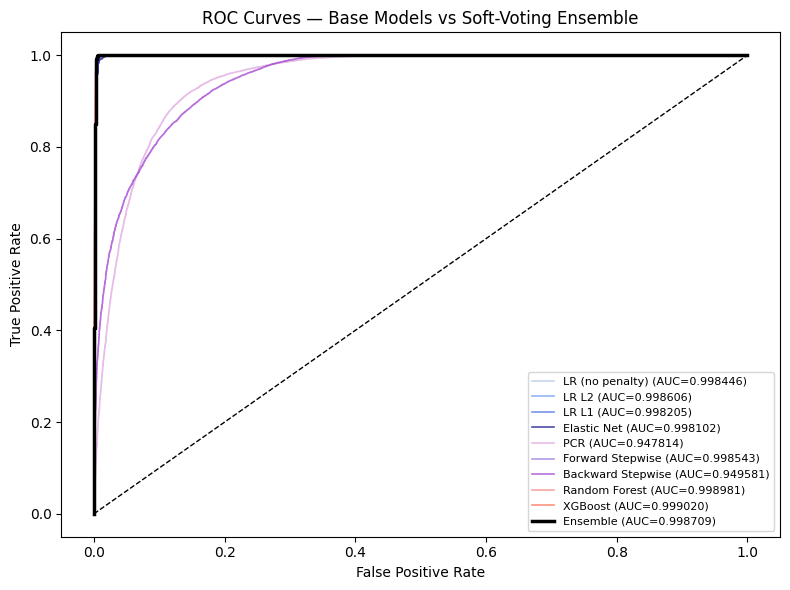

In [15]:
colors = [
    'lightsteelblue', 'cornflowerblue', 'royalblue', 'navy',
    'plum', 'mediumpurple', 'darkorchid',
    'lightcoral', 'tomato'
]

fig, ax = plt.subplots(figsize=(8, 6))

for (name, prob), color in zip(base_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.2, alpha=0.7,
            label=f'{name} (AUC={roc_auc:.6f})')

# Ensemble on top
fpr_ens, tpr_ens, _ = roc_curve(y_test, prob_ensemble)
auc_ens = auc(fpr_ens, tpr_ens)
ax.plot(fpr_ens, tpr_ens, color='black', lw=2.5,
        label=f'Ensemble (AUC={auc_ens:.6f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Base Models vs Soft-Voting Ensemble')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Ensemble Confusion Matrix

Ensemble — Confusion Matrix:
  TN=20,066, FP=123
  FN=13, TP=26,957


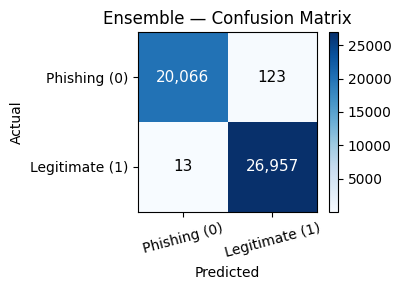

In [16]:
cm = confusion_matrix(y_test, pred_ensemble)
print('Ensemble — Confusion Matrix:')
print(f'  TN={cm[0,0]:,}, FP={cm[0,1]:,}')
print(f'  FN={cm[1,0]:,}, TP={cm[1,1]:,}')

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
tick_labels = ['Phishing (0)', 'Legitimate (1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels, rotation=15)
ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Ensemble — Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
plt.tight_layout()
plt.show()